In [1]:
# Base packages
import numpy as np
import matplotlib.pyplot as plt
import os
import copy

# I/O
import glob
from skimage import io
from PIL import Image
import h5py
import json
import pickle

# Pytorch
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import ToTensor

# Data Augmentation
import imgaug as ia
import imgaug.augmenters as iaa
from imgaug.augmentables.segmaps import SegmentationMapsOnImage
ia.seed(2)

# Plots
import seaborn as sns
import pandas as pd
from textwrap import wrap
import matplotlib.patheffects as path_effects
import statsmodels.api as sm

# Measurements and Metrics
from sklearn import metrics as skmetrics
from skimage import measure

from scipy.stats import pearsonr

from datetime import datetime

random_state = np.random.RandomState(42)

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from ultralytics import YOLO
import cv2
import torchvision.models.segmentation
import torch
import nms.nms

In [2]:
torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [3]:
def file_list_dict(img_list, gt_list):
    # Returns a dictionary with the list of images and corresponding ground truth
    file_list = {"imgs": img_list,
      "gt": gt_list}
    
    return file_list

In [4]:
class GVHD_Dataset(Dataset):
    def __init__(self, files, mode, transform=None):
        self.transform = transform 
        self.files = files
        self.mode = mode
        
    def __len__(self):
        size=len(self.files["imgs"])
        return size
    
    def __getitem__(self, idx):
        path_img = self.files["imgs"][idx]
        path_mask = self.files["gt"][idx]
        
        if self.mode == 'test':
            image = path_img
            mask = path_mask
        else:
            image = io.imread(path_img)
            mask = io.imread(path_mask)[:,:,0]
        
        return image, mask

In [5]:
def patch_extractor(img, patch_size = 256, stride=32):
    width = img.shape[1]
    height = img.shape[0]
    patch_list = []
    
    if len(img.shape) == 3:
        for j in range(0, width-patch_size+stride, stride):
            for i in range(0, height-patch_size+stride, stride):
                patch_list.extend([img[i:i+patch_size, j:j+patch_size, :]])
    elif len(img.shape) == 2:
        for j in range(0, width-patch_size+stride, stride):
            for i in range(0, height-patch_size+stride, stride):
                patch_list.extend([img[i:i+patch_size, j:j+patch_size]])
    
    return patch_list

In [6]:
def lesion_count(binary_mask):
    mask_labelled = measure.label(binary_mask)
    lesion_number = len(np.unique(mask_labelled))-1
    
    return lesion_number

In [7]:
def patched_inference_list_YOLO(img, model, patch_size = 128, stride=32, include_mask = True):
    pad_val = patch_size-stride
    img_pad = np.pad(img, pad_width=[(pad_val, pad_val),(pad_val, pad_val),(0, 0)], mode='constant')
    
    patch_list = patch_extractor(img_pad, patch_size, stride)
    
    files_test = file_list_dict(patch_list, patch_list)
    gvhd_data_test = GVHD_Dataset(files_test,'test',composed)
    
    bbox_list = []
    conf_list = []
    mask_list = []
    index_list = []
    edge_list = []
    num_patches_h = len(range(0, img_pad.shape[0]-patch_size+stride, stride))
    num_patches_w = len(range(0, img_pad.shape[1]-patch_size+stride, stride))
    for img_idx in range(len(patch_list)):
        h_index = img_idx % num_patches_h
        w_index = np.floor(img_idx / num_patches_h)
        image, _ = gvhd_data_test[img_idx]
        pred = model(image, save_conf = True, imgsz = image.shape[0:2])
        if not pred[0].masks is None:
            for i in range(len(pred[0].masks.data)):
                box = pred[0].boxes.xyxy[i].detach().cpu().numpy()
                if (box[0] < 1) or (box[1] < 1) or (box[2] > patch_size-2) or (box[3] > patch_size-2):
                    edge_list.append(1)
                else:
                    edge_list.append(0)
                box[0] = box[0] + w_index*stride
                box[2] = box[2] + w_index*stride
                box[1] = box[1] + h_index*stride
                box[3] = box[3] + h_index*stride
                bbox_list.append(box)
                conf = pred[0].boxes.conf[i].detach().cpu().numpy()
                conf = float(conf)
                conf_list.append(conf)
                if include_mask:
                    mask = pred[0].masks.data[i].detach().cpu().numpy()
                    mask_list.append(mask)
                    index_list.append((h_index, w_index))
    if include_mask:
        return bbox_list, conf_list, edge_list, mask_list, index_list
    else:
        return bbox_list, conf_list, edge_list

In [8]:
def patched_inference_list_RCNN(img, model, patch_size = 256, stride=32, include_mask = True):
    pad_val = patch_size-stride
    img_pad = np.pad(img, pad_width=[(pad_val, pad_val),(pad_val, pad_val),(0, 0)], mode='constant')
    
    patch_list = patch_extractor(img_pad, patch_size, stride)
    
    files_test = file_list_dict(patch_list, patch_list)
    gvhd_data_test = GVHD_Dataset(files_test,'test',composed)
    
    bbox_list = []
    conf_list = []
    mask_list = []
    index_list = []
    edge_list = []
    num_patches_h = len(range(0, img_pad.shape[0]-patch_size+stride, stride))
    num_patches_w = len(range(0, img_pad.shape[1]-patch_size+stride, stride))
    for img_idx in range(len(patch_list)):
        h_index = img_idx % num_patches_h
        w_index = np.floor(img_idx / num_patches_h)
        image, _ = gvhd_data_test[img_idx]
        x_tensor = torch.as_tensor(image, dtype=torch.float32).unsqueeze(0)
        x_tensor = x_tensor.swapaxes(1, 3).swapaxes(2, 3)
        x_tensor = list(image.to(device) for image in x_tensor)
        with torch.no_grad():
            pred = model(x_tensor)
        for i in range(len(pred[0]['masks'])):
            box = pred[0]['boxes'][i].detach().cpu().numpy()
            if (box[0] < 1) or (box[1] < 1) or (box[2] > patch_size-2) or (box[3] > patch_size-2):
                edge_list.append(1)
            else:
                edge_list.append(0)
            box[0] = box[0] + w_index*stride
            box[2] = box[2] + w_index*stride
            box[1] = box[1] + h_index*stride
            box[3] = box[3] + h_index*stride
            bbox_list.append(box)
            conf = pred[0]['scores'][i].detach().cpu().numpy()
            conf = float(conf)
            conf_list.append(conf)
            if include_mask:
                mask = pred[0]['masks'][i,0].detach().cpu().numpy()
                mask_list.append(mask)
                index_list.append((h_index, w_index))
    if include_mask:
        return bbox_list, conf_list, edge_list, mask_list, index_list
    else:
        return bbox_list, conf_list, edge_list

In [9]:
def custom_nms(bounding_boxes, confidence_score, conf_threshold, iou_threshold, edge_list):
    # If no bounding boxes, return empty list
    if len(bounding_boxes) == 0:
        return [], {}
    
    grouping_dict = {}

    # Bounding boxes
    boxes = np.array(bounding_boxes)

    # coordinates of bounding boxes
    start_x = boxes[:, 0]
    start_y = boxes[:, 1]
    end_x = boxes[:, 2]
    end_y = boxes[:, 3]

    # Confidence scores of bounding boxes
    score = np.array(confidence_score)

    # Picked bounding boxes
    picked_boxes = []
    picked_score = []
    indices = []

    # Compute areas of bounding boxes
    areas = (end_x - start_x + 1) * (end_y - start_y + 1)

    # Sort by confidence score of bounding boxes
    order = np.argsort(score)
    order = np.array([i for i in order if confidence_score[i] > conf_threshold])

    # Iterate bounding boxes
    while order.size > 0:
        if edge_list[order[-1]] == 1:
            edge_list[order[-1]] = 0
            np.insert(order, 0, order[-1])
            order = order[0:-1]
            continue
        
        # The index of largest confidence score
        index = order[-1]

        # Pick the bounding box with largest confidence score
        picked_boxes.append(bounding_boxes[index])
        picked_score.append(confidence_score[index])
        indices.append(index)

        # Compute ordinates of intersection-over-union(IOU)
        x1 = np.maximum(start_x[index], start_x[order[:-1]])
        x2 = np.minimum(end_x[index], end_x[order[:-1]])
        y1 = np.maximum(start_y[index], start_y[order[:-1]])
        y2 = np.minimum(end_y[index], end_y[order[:-1]])

        # Compute areas of intersection-over-union
        w = np.maximum(0.0, x2 - x1 + 1)
        h = np.maximum(0.0, y2 - y1 + 1)
        intersection = w * h

        # Compute the ratio between intersection and union
        ratio = intersection / (areas[index] + areas[order[:-1]] - intersection)

        left = np.where(ratio < iou_threshold)
        merge = np.where(ratio >= iou_threshold)
        
        grouping_dict[index] = order[merge]
        order = order[left]

    return indices, grouping_dict

In [10]:
def seg_contour_overlay(mask_list,
                        image,
                        line_size=4,
                        fig_size=(16,16),
                        thresh=0.5,
                        color_list = ['blue','lime','magenta','yellow','red'],
                        save_fig=False,
                        save_name='overlay.jpg',
                        show_fig=True,
                        title='Contour Overlay',
                        save_fig_dpi=150,
                        contour_alpha=0.75
                       ):
    
    if torch.is_tensor(image):
        image = np.moveaxis(image.squeeze().cpu().numpy(), 0, -1)
    
    contour_list = []
    for mask in mask_list:
        contour_list.extend([measure.find_contours(mask, thresh)])
    
    fig, ax = plt.subplots(figsize=fig_size)
    image_new = image.copy()
    image[:,:,0] = image_new[:,:,2]
    image[:,:,2] = image_new[:,:,0]
    ax.imshow(image, cmap=plt.cm.gray, interpolation=None)
    
    color_select = 0
    for mask_contour in contour_list:
        for contour in mask_contour:
            ax.plot(contour[:, 1], contour[:, 0], linewidth=line_size, color=color_list[color_select],alpha=contour_alpha)
        color_select+=1

    ax.set_xticks([])
    ax.set_yticks([])
    plt.title(title, fontsize = 24)
    if save_fig:
        plt.savefig(save_name, dpi=save_fig_dpi, bbox_inches='tight', pad_inches = 0)
    if show_fig:
        plt.show()
    else:
        plt.close()

In [11]:
# w/o visual
def lesion_matching(final_indices, gt_mask, mask_list, index_list, grouping_dict):
    tp = 0
    fp = 0
    fn = 0
    
    patch_size = 256
    stride = 64
    pad_val = patch_size-stride

    padded_gt = np.pad(gt_mask, pad_width=[(pad_val, pad_val),(pad_val, pad_val)], mode='constant')
    gt_mask_labelled = measure.label(padded_gt)
    
    cpy_mask_list = copy.deepcopy(mask_list)
    cpy_index_list = copy.deepcopy(index_list)

    matched_gt_list = []
    for mask_index in final_indices:
        matched_gt = -1
        iou_val = 0
        pr_mask_full = np.zeros(padded_gt.shape)
        count_mask = np.zeros(padded_gt.shape)
        pr_mask_full[int(index_list[mask_index][0]*stride):int(index_list[mask_index][0]*stride+patch_size), int(index_list[mask_index][1]*stride):int(index_list[mask_index][1]*stride+patch_size)] =  mask_list[mask_index]
#         count_mask[int(index_list[mask_index][0]*stride):int(index_list[mask_index][0]*stride+patch_size), int(index_list[mask_index][1]*stride):int(index_list[mask_index][1]*stride+patch_size)] =  1
#         for i in range(len(grouping_dict[mask_index])):
#             pr_mask_full[int(index_list[np.array(grouping_dict[mask_index])[i]][0]*stride):int(index_list[np.array(grouping_dict[mask_index])[i]][0]*stride+patch_size), int(index_list[np.array(grouping_dict[mask_index])[i]][1]*stride):int(index_list[np.array(grouping_dict[mask_index])[i]][1]*stride+patch_size)] =  pr_mask_full[int(index_list[np.array(grouping_dict[mask_index])[i]][0]*stride):int(index_list[np.array(grouping_dict[mask_index])[i]][0]*stride+patch_size), int(index_list[np.array(grouping_dict[mask_index])[i]][1]*stride):int(index_list[np.array(grouping_dict[mask_index])[i]][1]*stride+patch_size)] + mask_list[np.array(grouping_dict[mask_index])[i]]
#             count_mask[int(index_list[grouping_dict[mask_index][i]][0]*stride):int(index_list[grouping_dict[mask_index][i]][0]*stride+patch_size), int(index_list[grouping_dict[mask_index][i]][1]*stride):int(index_list[grouping_dict[mask_index][i]][1]*stride+patch_size)] += (mask_list[grouping_dict[mask_index][i]] > 0)

        count_mask = np.maximum(count_mask, np.ones(padded_gt.shape))
        pr_mask_full = pr_mask_full / count_mask
        pr_mask_full = pr_mask_full > 0.5
        
        for region_label in range (1,len(np.unique(gt_mask_labelled))):
            if region_label not in matched_gt_list:
                current_region_mask = np.zeros(padded_gt.shape)
                current_region_mask[gt_mask_labelled == region_label] = 1
                curr_iou = np.sum(pr_mask_full[current_region_mask == 1])/(np.sum(pr_mask_full) + np.sum(gt_mask_labelled == region_label) - np.sum(pr_mask_full[current_region_mask == 1]))
                if curr_iou > 0:
                    if curr_iou > iou_val:
                        iou_val = curr_iou
                        matched_gt = region_label
        if matched_gt != -1:
            tp += 1
            matched_gt_list.append(matched_gt)
        else:
            fp += 1
    
    fn = len(np.unique(gt_mask_labelled)) - len(matched_gt_list)

    return tp, fp, fn

In [12]:
# w visual - TODO
def lesion_matching_visual(final_indices, gt_mask, mask_list, index_list, grouping_dict, current_photo_name, current_img):
    tp = 0
    fp = 0
    fn = 0
    
    patch_size = 256
    stride = 64
    pad_val = patch_size-stride

    padded_gt = np.pad(gt_mask, pad_width=[(pad_val, pad_val),(pad_val, pad_val)], mode='constant')
    gt_mask_labelled = measure.label(padded_gt)
    
    cpy_mask_list = copy.deepcopy(mask_list)
    cpy_index_list = copy.deepcopy(index_list)
    
    tp_map = np.zeros(padded_gt.shape)
    fp_map = np.zeros(padded_gt.shape)
    fn_map = np.zeros(padded_gt.shape)

    matched_gt_list = []
    for mask_index in final_indices:
        matched_gt = -1
        iou_val = 0
        pr_mask_full = np.zeros(padded_gt.shape)
        count_mask = np.zeros(padded_gt.shape)
        pr_mask_full[int(index_list[mask_index][0]*stride):int(index_list[mask_index][0]*stride+patch_size), int(index_list[mask_index][1]*stride):int(index_list[mask_index][1]*stride+patch_size)] =  mask_list[mask_index]
#         count_mask[int(index_list[mask_index][0]*stride):int(index_list[mask_index][0]*stride+patch_size), int(index_list[mask_index][1]*stride):int(index_list[mask_index][1]*stride+patch_size)] =  (mask_list[mask_index] > 0)
#         for i in range(len(grouping_dict[mask_index])):
#             pr_mask_full[int(index_list[np.array(grouping_dict[mask_index])[i]][0]*stride):int(index_list[np.array(grouping_dict[mask_index])[i]][0]*stride+patch_size), int(index_list[np.array(grouping_dict[mask_index])[i]][1]*stride):int(index_list[np.array(grouping_dict[mask_index])[i]][1]*stride+patch_size)] =  pr_mask_full[int(index_list[np.array(grouping_dict[mask_index])[i]][0]*stride):int(index_list[np.array(grouping_dict[mask_index])[i]][0]*stride+patch_size), int(index_list[np.array(grouping_dict[mask_index])[i]][1]*stride):int(index_list[np.array(grouping_dict[mask_index])[i]][1]*stride+patch_size)] + mask_list[np.array(grouping_dict[mask_index])[i]]
#             count_mask[int(index_list[grouping_dict[mask_index][i]][0]*stride):int(index_list[grouping_dict[mask_index][i]][0]*stride+patch_size), int(index_list[grouping_dict[mask_index][i]][1]*stride):int(index_list[grouping_dict[mask_index][i]][1]*stride+patch_size)] += (mask_list[grouping_dict[mask_index][i]] > 0)

#         count_mask = np.maximum(count_mask, np.ones(padded_gt.shape))
#         pr_mask_full = pr_mask_full / count_mask
        pr_mask_full = pr_mask_full > 0.5
        
        for region_label in range (1,len(np.unique(gt_mask_labelled))):
            if region_label not in matched_gt_list:
                current_region_mask = np.zeros(padded_gt.shape)
                current_region_mask[gt_mask_labelled == region_label] = 1
                curr_iou = np.sum(pr_mask_full[current_region_mask == 1])/(np.sum(pr_mask_full) + np.sum(gt_mask_labelled == region_label) - np.sum(pr_mask_full[current_region_mask == 1]))
                if curr_iou > 0:
                    if curr_iou > iou_val:
                        iou_val = curr_iou
                        matched_gt = region_label
        if matched_gt != -1:
            tp += 1
            tp_map = np.maximum(pr_mask_full, tp_map)
            matched_gt_list.append(matched_gt)
        else:
            fp += 1
            fp_map = np.maximum(pr_mask_full, fp_map)
    
    fn = len(np.unique(gt_mask_labelled)) - len(matched_gt_list)
    
    for i in range (1,len(np.unique(gt_mask_labelled))):
        if i not in matched_gt_list:
            current_region_mask = np.zeros(padded_gt.shape)
            current_region_mask[gt_mask_labelled == i] = 1
            fn_map = np.maximum(current_region_mask, fn_map)
            
    tp_map = tp_map[(256-64):(64-256),(256-64):(64-256)]
    fp_map = fp_map[(256-64):(64-256),(256-64):(64-256)]
    fn_map = fn_map[(256-64):(64-256),(256-64):(64-256)]
    
    seg_contour_overlay([tp_map,fp_map,fn_map],
                current_img,
                line_size=3,
                fig_size=(16,16),
                thresh=0.5,
                color_list = ['lime','blue','magenta','yellow','red'],
                save_fig=True,
                save_name=contour_save_root + current_photo_name + 'ColorCodedOverlay.jpg',
                show_fig=False,
                title='tp: ' + str(tp) + '\nfp: ' + str(fp) + '\nfn: ' + str(fn),
                save_fig_dpi=150,
                contour_alpha=1)

    return tp, fp, fn

In [13]:
def MPX_nms_thresholded(img_masked, gt_mask, bbox_list, conf_list, mask_list, index_list, edge_list, image_name):
    conf_threshold_list = np.arange(0.6, 1, 0.05)
#     iou_threshold_list = [0.05]
    iou_threshold_list = np.arange(0.05, 0.21, 0.05)
    
    patch_size = 256
    stride = 64
    pad_val = patch_size-stride
    
    bg_masked_indicies = []
    bg_masked_img  = np.pad(img_masked, pad_width=[(pad_val, pad_val),(pad_val, pad_val),(0, 0)], mode='constant')
    for les_index in range(len(conf_list)):
        if np.sum(bg_masked_img[int(bbox_list[les_index][1]):int(bbox_list[les_index][3]), int(bbox_list[les_index][0]):int(bbox_list[les_index][2])]) > 0:
            bg_masked_indicies.append(les_index)

    counter=0
    pr_count_list = np.zeros((len(iou_threshold_list), len(conf_threshold_list)))
    pr_metric_list = np.zeros((len(iou_threshold_list), len(conf_threshold_list)))
    current_gt_lesions = lesion_count(gt_mask)

    for (i, iou_threshold) in enumerate(iou_threshold_list):
        for (j, conf_threshold) in enumerate(conf_threshold_list):
            indices, grouping_dict = custom_nms(bbox_list, conf_list, conf_threshold, iou_threshold, edge_list)
            final_indices = np.intersect1d(indices, bg_masked_indicies)

            tp, fp, fn = lesion_matching(final_indices, gt_mask, mask_list, index_list, grouping_dict)

            pr_count_list[i][j] = len(final_indices)
            pr_metric_list[i][j] = tp/(tp+fp) + tp/(tp+fn)

            if counter % 10 == 0:
                print('Threshold number ' + str(counter) + r' / ' + str(len(conf_threshold_list)*len(iou_threshold_list)))
            counter+=1

    return pr_count_list, current_gt_lesions, pr_metric_list, iou_threshold_list, conf_threshold_list

In [14]:
torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

composed = {
    'image':transforms.Compose([ToTensor()]),
    'mask':transforms.Compose([ToTensor()]),
}

In [15]:
# Data folder (laptop)
data_root = ''

optimum_thresh_dir = r'.\final_YOLO_thresh_40' + os.sep
save_root = r'.\final_YOLO_output_40' + os.sep
os.makedirs(optimum_thresh_dir, exist_ok=True)
os.makedirs(save_root, exist_ok=True)

model_directory = '.' + os.sep + 'saved_models_patch_YOLO' + os.sep
model_list = sorted(glob.glob(model_directory + '*/weights/best.pt'))

full_img_dir = data_root + 'training_images' + os.sep
full_gt_dir = data_root + 'ground_truth' + os.sep

# optimum_thresh_dir = r'.\220604_MPX_JAMADerm_OptimumThresh' + os.sep

### NOTE: FAKED MASKED DIRECTORY FOR NOW - CALCULATIONS NOT ACUTALLY USED YET
full_masked_img_dir = full_gt_dir #data_root + 'images_bgmasked' + os.sep + 'ZC' + os.sep

print(len(model_list), model_list[0])

18 .\saved_models_patch_YOLO\051301\weights\best.pt


In [16]:
dir_list = sorted(glob.glob(full_img_dir + os.sep + '*'))

img_paths_dict = {}
gt_paths_dict = {}
masked_img_paths_dict = {}
patient_name_list = []
for dir_no in range(len(dir_list)):
    directory = dir_list[dir_no]
    patient_name = os.path.basename(directory)
    patient_name_list.extend([patient_name])
    
    img_paths_dict[patient_name] = sorted(glob.glob(directory + os.sep + '*.png'))
    gt_paths_dict[patient_name] = sorted(glob.glob(full_gt_dir + patient_name_list[dir_no] + os.sep+ '*.png'))
    masked_img_paths_dict[patient_name] = sorted(glob.glob(full_masked_img_dir + patient_name_list[dir_no] + os.sep+ '*.png'))

In [17]:
# now = datetime.now()
# current_time = now.strftime("%H:%M:%S")
# print("Current Time =", current_time)

# photo_filename_list = []
# for patient_name in patient_name_list:
#     img_counter = 0
#     model_found = False
#     for current_model_name in model_list:
#         current_model_name_split = current_model_name.split('\\')
#         if current_model_name_split[-2] == patient_name:
#             pretrained_model_name = current_model_name
#             model_found = True
    
#     if model_found:
#         print('Loading pretrained model "' + pretrained_model_name + '"')
#         device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')   # train on the GPU or on the CPU, if a GPU is not available
#         pretrained_model = YOLO(pretrained_model_name)

#         best_iou_thresh_dict = {}
#         best_conf_thresh_dict = {}
#         # Predict on TRAINING set (i.e. skip held-out patient)
#         for key in img_paths_dict: #run trhough all patients
#             if key is not patient_name: #exclude held-out patient)
#                 best_iou_thresh_dict[key] = []
#                 best_conf_thresh_dict[key] = []
#                 for img_no in range(len(img_paths_dict[key])): #predict on all photos for current patient
#                     current_img_path = img_paths_dict[key][img_no]
#                     current_gt_path = gt_paths_dict[key][img_no]
#                     current_masked_img_path = masked_img_paths_dict[key][img_no]

#                     current_image_name = os.path.basename(current_img_path)[:-4]

#                     photo_filename_list.extend([current_image_name])

#                     img_counter+=1
#                     print(str(img_counter)+' Testing image "' + current_image_name + '"')

#                     test_img = np.asarray(cv2.imread(current_img_path))
#                     test_gt = np.asarray(cv2.imread(current_gt_path))[:,:,0:3]
#                     test_img_masked = np.asarray(Image.open(current_masked_img_path))[:,:,0:3]

#                     test_gt_binary = np.max(test_gt,2).astype('bool')

#                     bbox_list, conf_list, edge_list, mask_list, index_list = patched_inference_list_YOLO(test_img, pretrained_model, patch_size=256, stride=64, include_mask = True)
                    
#                     pr_count_list, current_gt_lesions, pr_metric_list, iou_threshold_list, conf_threshold_list = MPX_nms_thresholded(test_img_masked, test_gt_binary, bbox_list, conf_list, mask_list, index_list, edge_list, current_image_name)

#                     best_conf_thresh_dict[key].append(conf_threshold_list[np.argmax(pr_metric_list)%len(conf_threshold_list)])
#                     best_iou_thresh_dict[key].append(iou_threshold_list[int(np.floor(np.argmax(pr_metric_list)/len(conf_threshold_list)))])

#         ## CALCULATE MEAN THRESHOLD FOR EACH PATIENT IN TRAIN SET
#         perPatient_iou_thresh_list = []
#         for key in best_iou_thresh_dict:
#             perPatient_iou_thresh_list.extend([np.mean(best_iou_thresh_dict[key])])
            
#         perPatient_conf_thresh_list = []
#         for key in best_conf_thresh_dict:
#             perPatient_conf_thresh_list.extend([np.mean(best_conf_thresh_dict[key])])

#         ## CACLUATE MEAN THRESHOLD ACROSS ALL PATIENTS
#         best_model_iou_threshold = np.mean(perPatient_iou_thresh_list)
        
#         with open(optimum_thresh_dir + 'OptimumThreshiou_patient-'+patient_name+'.json', 'w') as jsonfile:
#             json.dump(best_model_iou_threshold, jsonfile,  indent=4)

#         with open(optimum_thresh_dir + 'PerImageThreshiou_patient-'+patient_name+'.json', 'w') as jsonfile:
#             json.dump(best_iou_thresh_dict, jsonfile,  indent=4)
            
#         best_model_conf_threshold = np.mean(perPatient_conf_thresh_list)
        
#         with open(optimum_thresh_dir + 'OptimumThreshconf_patient-'+patient_name+'.json', 'w') as jsonfile:
#             json.dump(best_model_conf_threshold, jsonfile,  indent=4)

#         with open(optimum_thresh_dir + 'PerImageThreshconf_patient-'+patient_name+'.json', 'w') as jsonfile:
#             json.dump(best_conf_thresh_dict, jsonfile,  indent=4)

#     else:
#         print('No model for patient "' + patient_name + '"')
    
#     now = datetime.now()
#     current_time = now.strftime("%H:%M:%S")
#     print("Current Time =", current_time)

In [18]:
# optimum_iou_thresh_jsons = sorted(glob.glob(optimum_thresh_dir + 'OptimumThreshiou_*.json'))
# optimum_conf_thresh_jsons = sorted(glob.glob(optimum_thresh_dir + 'OptimumThreshconf_*.json'))

# optimum_iou_thresh_dict = {}
# optimum_conf_thresh_dict = {}
# for json_file in optimum_iou_thresh_jsons:
#     path_split = os.path.basename(json_file).split('patient-')
#     current_patient_name = path_split[1][:-5]
    
#     with open(json_file, 'r') as f:
#         optimum_iou_thresh_dict[current_patient_name] = json.load(f)

# for json_file in optimum_conf_thresh_jsons:
#     path_split = os.path.basename(json_file).split('patient-')
#     current_patient_name = path_split[1][:-5]
    
#     with open(json_file, 'r') as f:
#         optimum_conf_thresh_dict[current_patient_name] = json.load(f)

# print(optimum_iou_thresh_dict)
# print(optimum_conf_thresh_dict)

In [19]:
contour_save_root = r'.\final_YOLO_contour_40' + os.sep
os.makedirs(contour_save_root, exist_ok=True)

# list_of_test_patients = list(optimum_iou_thresh_dict.keys())
list_of_test_patients = patient_name_list

YOLO_metric_arr = []
for patient_name in list_of_test_patients:
    model_found = False
    for current_model_name in model_list:
        current_model_name_split = current_model_name.split('\\')
        if current_model_name_split[-3] == patient_name:
            pretrained_model_name = current_model_name
            model_found = True
    
    if model_found:
        print('Loading pretrained model "' + pretrained_model_name + '"')
        device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')   # train on the GPU or on the CPU, if a GPU is not available
#         pretrained_model = YOLO('yolov8n.pt')  # load an official model
        pretrained_model = YOLO(pretrained_model_name)
    else:
        print('No model found for patient ' + patient_name)
        break
    
    # Predict on held-out patient
    for img_no in range(len(img_paths_dict[patient_name])): #predict on all photos for current patient
        current_img_path = img_paths_dict[patient_name][img_no]
        current_gt_path = gt_paths_dict[patient_name][img_no]
        
        current_image_name = os.path.basename(current_img_path)[:-4]
        
        print(' Testing image "' + current_image_name + '"')
        
        test_img = np.asarray(cv2.imread(current_img_path))
        test_gt = np.asarray(cv2.imread(current_gt_path))[:,:,0:3]
        test_gt_binary = np.max(test_gt,2).astype('bool')
        
        bbox_list, conf_list, edge_list, mask_list, index_list = patched_inference_list_YOLO(test_img, pretrained_model, patch_size=256, stride=64)
#         indicies, grouping_dict = custom_nms(bbox_list, conf_list, optimum_conf_thresh_dict[patient_name], optimum_iou_thresh_dict[patient_name], edge_list)
        indicies, grouping_dict = custom_nms(bbox_list, conf_list, 0, 0.05, edge_list)

        patch_size = 256
        stride = 64
        pad_val = patch_size-stride
        
        bg_masked_indicies = []
        bg_masked_name = current_img_path.replace('training_images', 'images_bgmasked')
        bg_masked_name = bg_masked_name.replace('.png', '_masked.png')
        bg_masked_img = cv2.imread(bg_masked_name)
        bg_masked_img = np.pad(bg_masked_img, pad_width=[(pad_val, pad_val),(pad_val, pad_val),(0, 0)], mode='constant')
        for les_index in indicies:
            if np.sum(bg_masked_img[int(bbox_list[les_index][1]):int(bbox_list[les_index][3]), int(bbox_list[les_index][0]):int(bbox_list[les_index][2])]) > 0:
                bg_masked_indicies.append(les_index)
        
        lesion_count = len(bg_masked_indicies)
        tp, fp, fn = lesion_matching_visual(bg_masked_indicies, test_gt_binary, mask_list, index_list, grouping_dict, current_image_name, test_img)
        print(tp)
        print(fp)
        print(fn)
        YOLO_metric_arr.append(tp/(tp+fp) + tp/(tp+fn))
        
        pr_mask_full = np.zeros(np.pad(test_img, pad_width=[(pad_val, pad_val),(pad_val, pad_val),(0, 0)], mode='constant').shape[0:2])
        count_mask = np.zeros(pr_mask_full.shape)
        for mask_index in bg_masked_indicies:
            for i in range(len(grouping_dict[mask_index])):
                pr_mask_full[int(index_list[grouping_dict[mask_index][i]][0]*stride):int(index_list[grouping_dict[mask_index][i]][0]*stride+patch_size), int(index_list[grouping_dict[mask_index][i]][1]*stride):int(index_list[grouping_dict[mask_index][i]][1]*stride+patch_size)] =  pr_mask_full[int(index_list[grouping_dict[mask_index][i]][0]*stride):int(index_list[grouping_dict[mask_index][i]][0]*stride+patch_size), int(index_list[grouping_dict[mask_index][i]][1]*stride):int(index_list[grouping_dict[mask_index][i]][1]*stride+patch_size)] + mask_list[grouping_dict[mask_index][i]]
                count_mask[int(index_list[grouping_dict[mask_index][i]][0]*stride):int(index_list[grouping_dict[mask_index][i]][0]*stride+patch_size), int(index_list[grouping_dict[mask_index][i]][1]*stride):int(index_list[grouping_dict[mask_index][i]][1]*stride+patch_size)] += (mask_list[grouping_dict[mask_index][i]] > 0)
        count_mask = np.maximum(count_mask, np.ones(pr_mask_full.shape))
        pr_mask_full = pr_mask_full / count_mask
        pr_mask_optimum = pr_mask_full > 0.5
        pr_mask_optimum = pr_mask_optimum[(256-64):(64-256),(256-64):(64-256)]
        pr_mask_full = pr_mask_full[(256-64):(64-256),(256-64):(64-256)]
        
        os.makedirs(save_root + os.sep + patient_name, exist_ok=True)
        save_name = save_root + os.sep + patient_name + os.sep + current_image_name + '_PredictionResults.h5'
        
        with h5py.File(save_name, 'w') as hdf:
            hdf.create_dataset('img', data=test_img, dtype='uint8')
            hdf.create_dataset('gt_mask', data=(test_gt_binary*255).astype('uint8'), dtype='uint8')
            hdf.create_dataset('pr_map', data=(pr_mask_full).astype('double'), dtype='double')
            hdf.create_dataset('pr_mask_optimum', data=(pr_mask_optimum*255).astype('uint8'), dtype='uint8')
            hdf.create_dataset('lesion_count', data=lesion_count, dtype='int')

Loading pretrained model ".\saved_models_patch_YOLO\051301\weights\best.pt"
 Testing image "051301 D2_06"



0: 256x256 (no detections), 9.0ms
Speed: 3.0ms preprocess, 9.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 1.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 1.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 9.0ms
Speed: 1.0ms preprocess, 9.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 9.0ms
Speed: 1.0ms preprocess, 9.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 1.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 1.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 0.0ms 


0: 256x256 (no detections), 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 1.0ms preprocess, 8.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 lesion, 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 lesion, 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 2 lesions, 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 2.0ms postprocess per imag


0: 256x256 5 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 5 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 lesion, 8.0ms
Speed: 1.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 lesion, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 lesion, 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 1.0ms preprocess, 8.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 lesion, 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 2 lesions, 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256


0: 256x256 (no detections), 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 lesion, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 lesion, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 lesion, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image

...


0: 256x256 2 lesions, 8.0ms
Speed: 1.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 5 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 8 lesions, 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 14 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 22 lesions, 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 19 lesions, 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 19 lesions, 8.0ms
Speed: 1.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 15 lesions, 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 

Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 32 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 28 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 21 lesions, 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 11 lesions, 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 4 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 9 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 7 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 13 lesions, 7


0: 256x256 (no detections), 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 1 lesion, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 4 lesions, 8.0ms
Speed: 0.0ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 11 lesions, 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 23 lesions, 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 41 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 45 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1

Speed: 0.0ms preprocess, 7.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detections), 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 4 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 8 lesions, 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 9 lesions, 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 9 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 8 lesions, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 3 lesions, 7.0ms
Speed: 0.0ms preprocess, 7.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 (no detecti

168
27
92


In [20]:
unet_prediction_dir = data_root + 'model_predictions_220604' + os.sep
unet_prediction_list = sorted(glob.glob(unet_prediction_dir + os.sep + '**' + os.sep + '*.h5', recursive=True))

In [21]:
unet_metric_arr = []
for img_no in range(len(unet_prediction_list)):
    current_filename = unet_prediction_list[img_no]
    current_photo_name = os.path.basename(current_filename)[:-20]
    print(current_filename)

    with h5py.File(current_filename, 'r') as hdf:
#         current_img = np.asarray(hdf['img'])
        current_gt = np.asarray(hdf['gt_mask'])
        current_predict_mask = np.asarray(hdf['pr_mask_optimum'])
        
    bg_masked_name = current_filename.replace('model_predictions_220604', 'images_bgmasked')
    bg_masked_name = bg_masked_name.replace('_PredictionResults.h5', '_masked.png')
    bg_masked_img = cv2.imread(bg_masked_name)
    bg_masked_img = np.max(bg_masked_img, axis = 2)
    current_predict_mask[bg_masked_img == 0] = 0
    
    current_img = np.asarray(cv2.imread(current_filename.split('_PredictionResults')[0].replace('model_predictions_220604', 'training_images') + '.png'))

    tp = 0
    fp = 0
    fn = 0
    
    gt_mask_labelled = measure.label(current_gt)
    pr_mask_labelled = measure.label(current_predict_mask)

    tp_map = np.zeros(current_gt.shape)
    fp_map = np.zeros(current_gt.shape)
    fn_map = np.zeros(current_gt.shape)

    matched_gt_list = []
    for pred_label in range (1,len(np.unique(pr_mask_labelled))):
        pr_mask_full = np.zeros(current_predict_mask.shape)
        pr_mask_full[pr_mask_labelled == pred_label] = 1

        matched_gt = -1
        iou_val = 0

        for region_label in range (1,len(np.unique(gt_mask_labelled))):
            if region_label not in matched_gt_list:
                current_region_mask = np.zeros(current_gt.shape)
                current_region_mask[gt_mask_labelled == region_label] = 1
                curr_iou = np.sum(pr_mask_full[current_region_mask == 1])/(np.sum(pr_mask_full) + np.sum(gt_mask_labelled == region_label) - np.sum(pr_mask_full[current_region_mask == 1]))
                if curr_iou > 0.01:
                    if curr_iou > iou_val:
                        iou_val = curr_iou
                        matched_gt = region_label
        if matched_gt != -1:
            tp += 1
            matched_gt_list.append(matched_gt)
            tp_map = np.maximum(pr_mask_full, tp_map)
        else:
            fp += 1
            fp_map = np.maximum(pr_mask_full, fp_map)
  
    fn = len(np.unique(gt_mask_labelled)) - len(matched_gt_list)
    for i in range (1,len(np.unique(gt_mask_labelled))):
        if i not in matched_gt_list:
            current_region_mask = np.zeros(current_gt.shape)
            current_region_mask[gt_mask_labelled == i] = 1
            fn_map = np.maximum(current_region_mask, fn_map)         
            
    print(tp)
    print(fp)
    print(fn)
    unet_metric_arr.append(tp/(tp+fp) + tp/(tp+fn))
    
    seg_contour_overlay([tp_map,fp_map,fn_map],
            current_img,
            line_size=3,
            fig_size=(16,16),
            thresh=0.5,
            color_list = ['lime','blue','magenta','yellow','red'],
            save_fig=True,
            save_name='final_Unet_contour' + os.sep + current_photo_name + 'ColorCodedOverlay.jpg',
            show_fig=False,
            title='tp: ' + str(tp) + '\nfp: ' + str(fp) + '\nfn: ' + str(fn),
            save_fig_dpi=150,
            contour_alpha=1)

model_predictions_220604\051301\051301 D2_06_PredictionResults.h5
27
4
7
model_predictions_220604\051301\051301 D2_07_PredictionResults.h5
62
4
13
model_predictions_220604\051301\051301 D2_08_PredictionResults.h5
29
7
32
model_predictions_220604\051301\051301 D8_02_PredictionResults.h5
128
3
24
model_predictions_220604\051302\051302 D2_01_PredictionResults.h5
30
27
6
model_predictions_220604\051302\051302 D2_02_PredictionResults.h5
19
17
9
model_predictions_220604\051307\051307 010_PredictionResults.h5
16
3
10
model_predictions_220604\051307\051307 012_PredictionResults.h5
14
1
7
model_predictions_220604\051308\051308 001_PredictionResults.h5
73
20
21
model_predictions_220604\051308\051308 004_PredictionResults.h5
41
12
3
model_predictions_220604\051308\051308 005_PredictionResults.h5
31
6
4
model_predictions_220604\051308\051308 007_PredictionResults.h5
52
24
5
model_predictions_220604\051308\051308 009_PredictionResults.h5
67
14
5
model_predictions_220604\051308\051308 010_Prediction

In [22]:
def add_median_labels(ax,color='white',foreground_color='white',fontsize=None,median_outline=False):
    lines = ax.get_lines()
    # determine number of lines per box (this varies with/without fliers)
    boxes = [c for c in ax.get_children() if type(c).__name__ == 'PathPatch']
    lines_per_box = int(len(lines) / len(boxes))
    # iterate over median lines
    median_list = []
    for median in lines[4:len(lines):lines_per_box]:
        # display median value at center of median line
        x, y = (data.mean() for data in median.get_data())
        # choose value depending on horizontal or vertical plot orientation
        value = x if (median.get_xdata()[1]-median.get_xdata()[0]) == 0 else y
        if fontsize is not None:
            text = ax.text(x, y, f'{value:.2f}', ha='center', va='center',
                           fontweight='bold', color=color, fontsize=fontsize)
        else:
            text = ax.text(x, y, f'{value:.2f}', ha='center', va='center',
                           fontweight='bold', color=color)
        
        if median_outline:
            # create median-colored border around white text for contrast
            text.set_path_effects([
                path_effects.Stroke(linewidth=3, foreground=foreground_color),#median.get_color()),
                path_effects.Normal(),
            ])
        median_list.extend([value])
    return median_list

In [23]:
def boxplot_full_set_v2(df,
                        colors = ["lightgreen", "lightyellow"],
                        figsize=(4.5,9),
                        median_labels = True,
                        swarmsize=6,
                        swarmpalette=['0.25','0.25'],
                        swarm_marker='o',
                        ylim=(-0.05,1.05),
                        fontsize=None,
                        savefig=False,
                        showfig=True,
                        savename='boxplot_v2',
                        gridlines="both",
                        title="Boxplot v2",
                        titlewrap=35,
                        xlabel='Group',
                        xlabel_size = None,
                        xtick_rotation = 0,
                        ylabel="Value",
                        ylabel_size = None,
                        y_axis_right=False,
                        median_color='white',
                        median_outline=False,
                        median_outline_color ='black',
                        median_fontsize=None,
                        show_means=False,
                        meanline=False,
                        meanprops={"marker":"o",
                                   "markerfacecolor":"white", 
                                   "markeredgecolor":"red",
                                   "markersize":"16"}
                       ):
    
    sns.set_palette(sns.color_palette(colors))
    sns.set_style("whitegrid", {"axes.grid.which":gridlines})
    
    if fontsize is not None:
        plt.rcParams.update({'font.size': fontsize})
        
    plt.figure(figsize=figsize)
        
    ax = sns.swarmplot(data=df,
                       #color=".25",
                       palette=swarmpalette,
                       size=swarmsize,
                       marker=swarm_marker)
    
    if show_means and meanline:
        ax = sns.boxplot(data=df,
                         fliersize=0,
                         showmeans=True,
                         meanline=True,
                         meanprops=meanprops
                        )
        print('meanline!')
    elif show_means:
        ax = sns.boxplot(data=df,
                         fliersize=0,
                         showmeans=True,
                         meanprops=meanprops
                        )
    
    else:
        ax = sns.boxplot(data=df,fliersize=0)
    
    if median_labels:
        add_median_labels(ax, median_color, median_outline_color, median_fontsize, median_outline=median_outline)

    plt.ylim(ylim)
    
    plt.title("\n".join(wrap(title,titlewrap)))
    
    if xlabel_size is None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel(xlabel, fontsize=xlabel_size)
    
    if ylabel_size is None:
        plt.ylabel(ylabel)
    else:
        plt.ylabel(ylabel, fontsize=ylabel_size)
    
    if y_axis_right:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
    
    plt.xticks(rotation = xtick_rotation)
    
    if savefig:
        plt.savefig(savename + '.png', dpi=150, bbox_inches='tight')
        plt.savefig(savename + '.pdf', dpi=150, bbox_inches='tight')
    
    if showfig:
        plt.show()
    else:
        plt.close()
    
    if fontsize is not None:
        plt.rcParams.update({'font.size': default_fontsize})

In [24]:
fontsize = 18
plt.rcParams.update({'font.size': fontsize})
default_fontsize = fontsize

meanline!


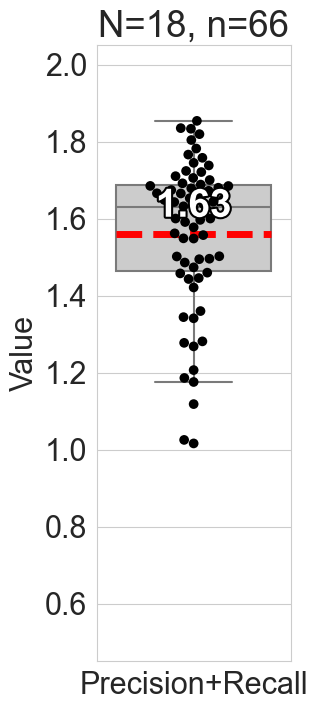

In [25]:
unet_df = pd.DataFrame(
    {
        'Precision+Recall':unet_metric_arr,
    }
)

boxplot_full_set_v2(unet_df,
                 figsize=(2.5,8),
                 fontsize=22,
                 swarmsize=7,
                 savename="PrecisionRecall_UNet",
                 title='N=18, n=66',
                 titlewrap=25,
                 xlabel='',
                 ylabel='Value',
                 ylim=(0.45,2.05),
                 colors = ['0.8','0.8'],
                 #colors = ["#6BA3F0"],
                 swarmpalette=["0.0"],
                 median_labels=True,
                 median_color='white',
                 median_outline=True,
                 median_outline_color='0.0',
                 median_fontsize=28,
                 show_means=True,
                 meanline=True,
                 meanprops={"c":"red",
                           "ls":"--",
                           'linewidth':'5'},
                 savefig=False
                )

meanline!


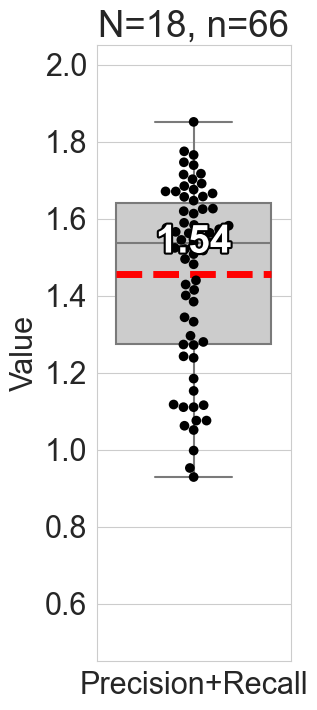

In [26]:
yolo_df = pd.DataFrame(
    {
        'Precision+Recall':YOLO_metric_arr,
    }
)

boxplot_full_set_v2(yolo_df,
                 figsize=(2.5,8),
                 fontsize=22,
                 swarmsize=7,
                 savename="PrecisionRecall_UNet",
                 title='N=18, n=66',
                 titlewrap=25,
                 xlabel='',
                 ylabel='Value',
                 ylim=(0.45,2.05),
                 colors = ['0.8','0.8'],
                 #colors = ["#6BA3F0"],
                 swarmpalette=["0.0"],
                 median_labels=True,
                 median_color='white',
                 median_outline=True,
                 median_outline_color='0.0',
                 median_fontsize=28,
                 show_means=True,
                 meanline=True,
                 meanprops={"c":"red",
                           "ls":"--",
                           'linewidth':'5'},
                 savefig=False
                )

In [27]:
yolo_df

,Precision+Recall
0,1.272727
1,1.670303
2,0.997268
3,1.765083
4,0.952020
...,...
61,1.075099
62,1.115196
63,1.050725
64,1.561698


In [28]:
unet_df

,Precision+Recall
0,1.665085
1,1.766061
2,1.280965
3,1.819204
4,1.359649
...,...
61,1.343874
62,1.175439
63,1.118012
64,1.648201
